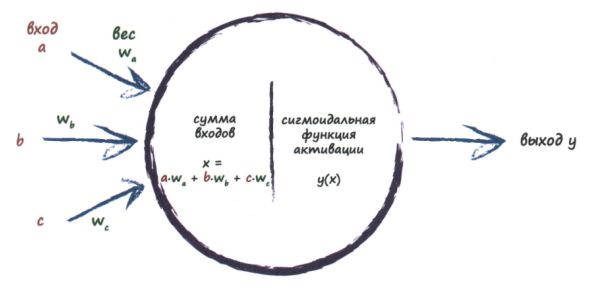

#1. **Введение в нейронные сети**
### 1.1. Основы работы нейрона
   
Каждый нейрон в сети принимает входные сигналы, суммирует их и пропускает через функцию активации, чтобы получить выходной сигнал. В данном случае используется сигмоидная функция активации:  

$$
y = \frac{1}{1 + e^{-x}},
$$

где $ x $ — это сумма входных сигналов, а $ y $ — выход нейрона. Сигмоида преобразует вход в значение от 0 до 1, что помогает сети работать с нелинейными данными.

### 1.2. Роль весовых коэффициентов

Теперь о весовых коэффициентах. Веса — это параметры, которые определяют, насколько сильно каждый входной сигнал влияет на выход нейрона. Изначально веса выбираются случайным образом. В данном примере используются следующие значения:  
$$ w_{1,1} = 0,9 $$
$$ w_{1,2} = 0,2 $$
$$ w_{2,1} = 0,3 $$
$$ w_{2,2} = 0,8 $$

### 1.3. Случайная инициализация весов

Случайная инициализация весов — это стандартный подход, который помогает избежать симметрии в сети и позволяет ей эффективно обучаться. В процессе обучения веса постепенно корректируются на основе тренировочных данных, чтобы минимизировать ошибку. Например, в простом линейном классификаторе мы также начинали со случайного наклона прямой и улучшали его с каждым шагом обучения. То же самое происходит и в нейронных сетях.

В данной сети всего четыре веса, так как она состоит из двух слоёв, каждый из которых содержит по два нейрона. Это небольшой пример, но он иллюстрирует базовый принцип работы нейронных сетей: входные сигналы умножаются на веса, суммируются, проходят через функцию активации, и результат передаётся дальше. На диаграмме ниже все связи между нейронами обозначены соответствующими весами.

> *Случайная инициализация весов важна, потому что если все веса начать с одинаковых значений, нейроны будут обучаться одинаково, что снизит эффективность сети. Кроме того, сигмоидная функция активации, хотя и проста, может вызывать проблему "затухания градиентов" при обучении глубоких сетей, поэтому в современных архитектурах часто используют другие функции, например ReLU. Однако для понимания основ сигмоида подходит идеально.*



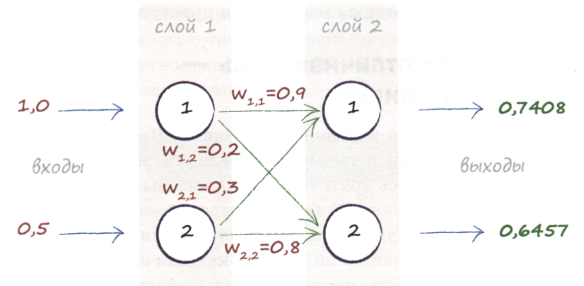

In [81]:
import numpy as np
sigmoid = lambda x: 1/(1+np.power(np.e, -x))
x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8

In [82]:
#code 1
w1 = np.array([w11, w12])
w2 = np.array([w21, w22])
res = sigmoid(w1*x1 + w2*x2)
res
#(0.7407748991821539, 0.6456563062257954)

array([0.7407749 , 0.64565631])

#2. **Расчёт сигналов в нейронной сети**
### 2.1. **Расчёт входного сигнала для узла 1 второго слоя**

Мы начинаем с узла 1 второго слоя. Этот нейрон получает сигналы от двух узлов входного слоя, значения которых равны 1,0 и 0,5. Каждый сигнал умножается на соответствующий вес:
- Вес для первого узла: $ w_{1,1} = 0,9 $
- Вес для второго узла: $ w_{2,1} = 0,3 $

Суммарный входной сигнал $ x $ для узла 1 второго слоя рассчитывается по формуле:
$$
x = (1,0 \cdot 0,9) + (0,5 \cdot 0,3) = 0,9 + 0,15 = 1,05
$$

> *Если бы мы не использовали веса, то просто сложили бы входные сигналы: $ 1,0 + 0,5 = 1,5 $. Однако веса позволяют регулировать влияние каждого входа на итоговый результат, что важно для обучения сети.*

---

### 2.2. **Применение функции активации**

Теперь, когда у нас есть $ x = 1,05 $, мы можем рассчитать выходной сигнал $ y $ с помощью сигмоидной функции активации:
$$
y = \frac{1}{1 + e^{-x}} = \frac{1}{1 + e^{-1,05}} \approx \frac{1}{1 + 0,3499} \approx 0,7408
$$

> *Сигмоидная функция преобразует входной сигнал в значение от 0 до 1, что позволяет сети работать с нелинейными зависимостями. В данном случае выход узла 1 второго слоя равен примерно 0,7408.*

---

### 2.3. **Расчёт для узла 2 второго слоя**

Аналогичные вычисления выполняются для узла 2 второго слоя. Его входные сигналы также равны 1,0 и 0,5, но веса другие:
- Вес для первого узла: $ w_{1,2} = 0,2 $
- Вес для второго узла: $ w_{2,2} = 0,8 $

Суммарный входной сигнал $ x $ для узла 2 второго слоя:
$$
x = (1,0 \cdot 0,2) + (0,5 \cdot 0,8) = 0,2 + 0,4 = 0,6
$$

Выходной сигнал $ y $ с помощью сигмоидной функции:
$$
y = \frac{1}{1 + e^{-0,6}} \approx \frac{1}{1 + 0,5488} \approx 0,6457
$$

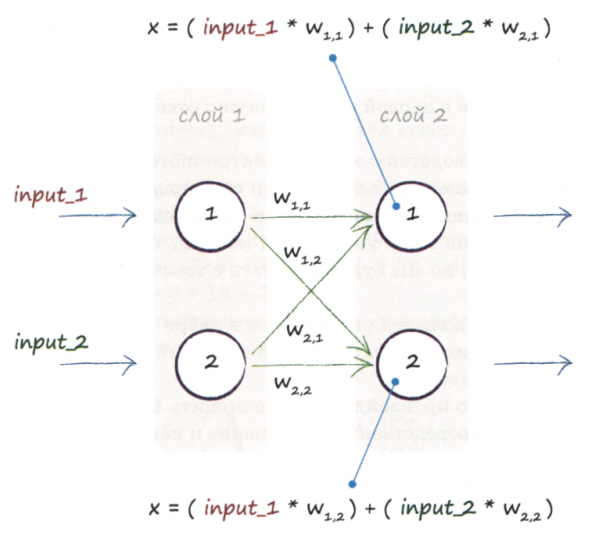

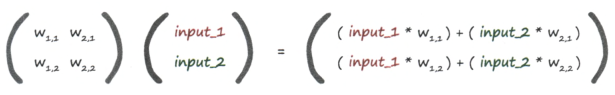

In [83]:
w = np.array([[w11, w21],[w12, w22]])
i = np.array([x1, x2])

In [84]:
#code 2
res = sigmoid(w @ i)
res
#array([0.7407749 , 0.64565631]) # не забываем про функцию активации

array([0.7407749 , 0.64565631])

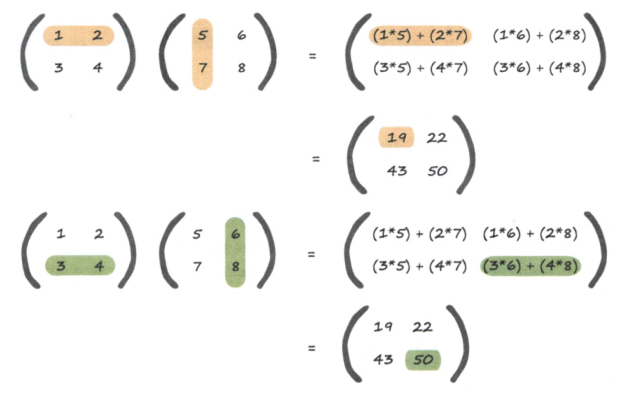

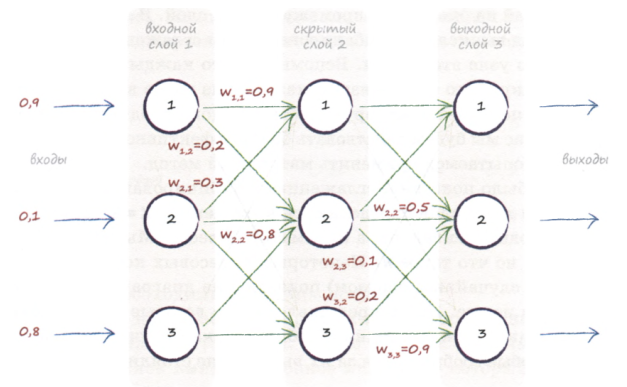

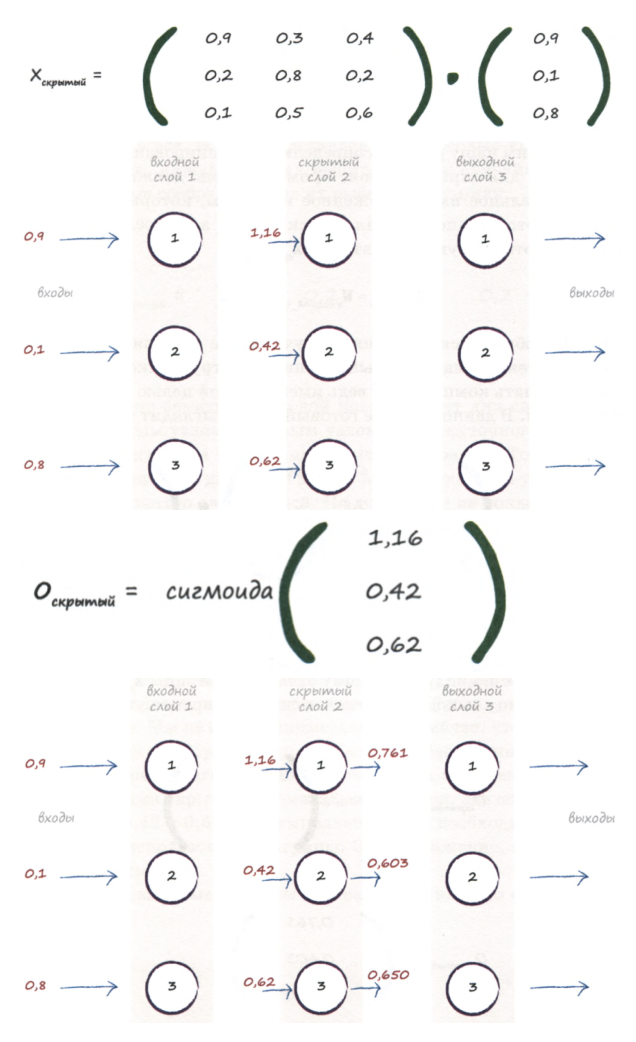

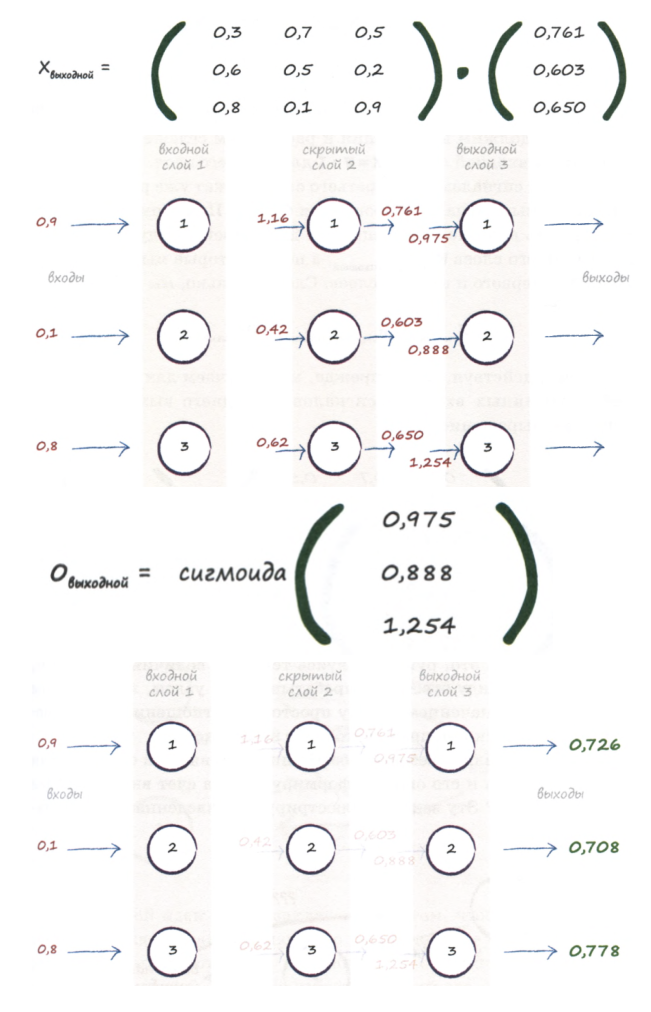

In [85]:
w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = np.array([0.9, 0.1, 0.8])

In [86]:
#code 3
res1 = sigmoid(w1 @ i)
res = sigmoid(w2 @ res1)
res
#array([0.72630335, 0.70859807, 0.77809706])

array([0.72630335, 0.70859807, 0.77809706])

#3. **Обратное распространение ошибки**

### 3.1. **Обновление весов при участии нескольких узлов**

Когда выходной сигнал сети и его ошибка формируются за счёт вкладов нескольких узлов (например, в скрытых слоях), возникает вопрос: как правильно обновить весовые коэффициенты связей? Эта задача решается с помощью метода **обратного распространения ошибки** (backpropagation).

> *Ошибка на выходе сети зависит от вкладов всех узлов, через которые прошёл сигнал. Чтобы скорректировать веса, нужно понять, как каждый узел повлиял на итоговую ошибку. Это похоже на поиск "виновников" ошибки и их исправление.*

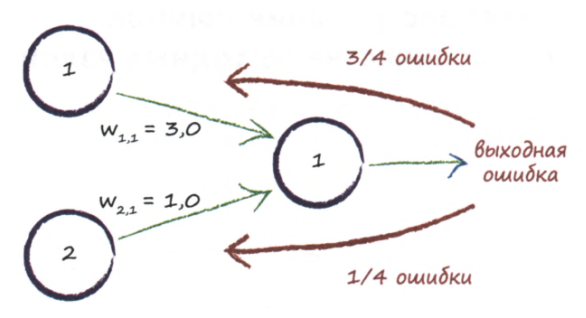

### 3.2. **Две роли весовых коэффициентов**

Весовые коэффициенты в нейронной сети выполняют две важные функции:
1. **Прямое распространение сигналов:**  
   Веса используются для расчёта сигналов, которые передаются от входного слоя к выходному. Мы уже видели, как это работает: входные сигналы умножаются на веса, суммируются и пропускаются через функцию активации.
   
2. **Обратное распространение ошибки:**  
   Веса также используются для передачи ошибки от выходного слоя обратно к входному. Это позволяет понять, как каждый вес повлиял на ошибку, и скорректировать его.

> *Прямое распространение — это "движение вперёд", когда сеть делает предсказание. Обратное распространение — это "движение назад", когда сеть учится на своих ошибках и корректирует веса.*

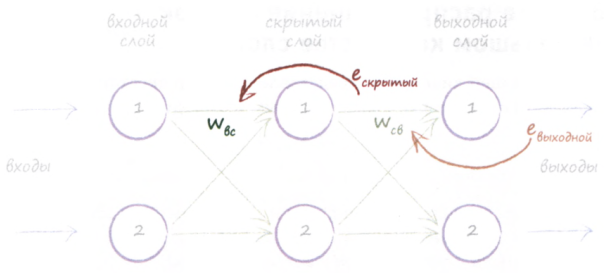

### 3.3. **Ошибка на нескольких узлах**

Ошибка может возникать на нескольких узлах одновременно, особенно если сеть ещё не обучена. Например, в скрытых слоях ошибка распределяется между всеми узлами, которые внесли вклад в неправильный результат.

> *Представьте, что несколько человек вместе решают задачу, и результат оказался неправильным. Чтобы исправить ошибку, нужно понять, кто из участников внёс больший вклад в ошибку, и скорректировать их действия. То же самое происходит в нейронной сети.*

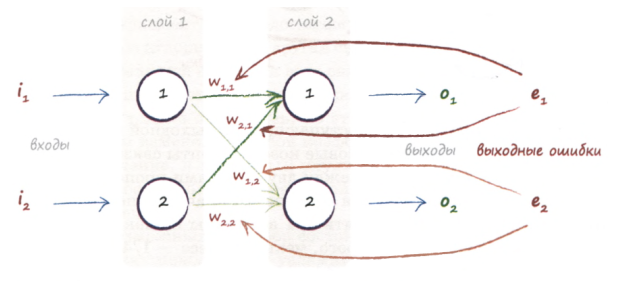

### 3.4. **Распределение ошибки между узлами**

Ошибка распределяется между узлами пропорционально их вкладу в результат. Это означает, что узлы, которые внесли больший вклад в ошибку, получат большую долю ошибки для коррекции.

**Пример:**  
Предположим, у нас есть два веса: $ w_{11} = 6 $ и $ w_{21} = 3 $. Ошибка $ e_1 $ будет распределена следующим образом:
- Доля ошибки для $ w_{11} $: $ \frac{6}{6 + 3} = \frac{2}{3} $
- Доля ошибки для $ w_{21} $: $ \frac{3}{6 + 3} = \frac{1}{3} $

> *Это справедливо, потому что $ w_{11} $ в два раза больше $ w_{21} $, а значит, он внёс больший вклад в ошибку. Соответственно, он получает большую долю ошибки для коррекции.*

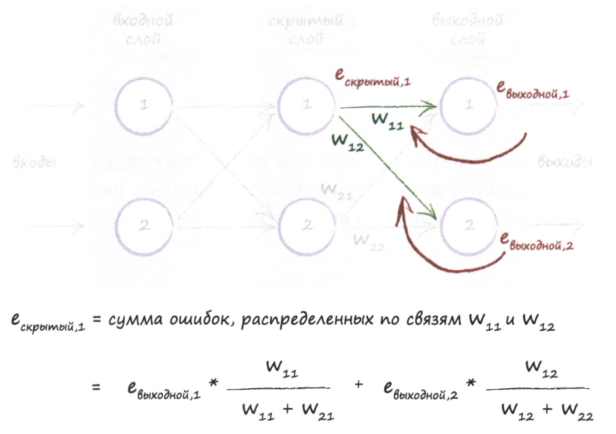

### 3.5. **Объединение ошибок для узлов промежуточного слоя**

Для узлов промежуточного слоя (скрытых слоёв) у нас нет "истинных" целевых значений, как для выходного слоя. Поэтому ошибка для таких узлов вычисляется как сумма ошибок, передаваемых от всех исходящих связей.

**Пример:**  
Если узел промежуточного слоя связан с двумя узлами следующего слоя, то его ошибка будет суммой ошибок, переданных через эти связи.

> *Этот подход позволяет нам оценить вклад каждого узла промежуточного слоя в итоговую ошибку, даже если у нас нет явного целевого значения для этого узла.*

---

### 3.6. **Важность обратного распространения ошибки**

Обратное распространение ошибки — это основа обучения нейронных сетей. Без него сеть не смогла бы "учиться" на своих ошибках и улучшать свои предсказания. Этот метод позволяет сети автоматически настраивать веса, чтобы минимизировать ошибку.

> *В реальных задачах обратное распространение ошибки часто сочетается с методом градиентного спуска, который помогает находить оптимальные значения весов. Также используются различные оптимизации (например, Adam или RMSprop), чтобы ускорить обучение и избежать проблем, таких как затухание градиентов.*

#4. **Пример обратного распространения ошибки**

### 4.1. **Распределение ошибки на выходном слое**

Рассмотрим, как ошибка распространяется обратно по сети. Предположим, на втором узле выходного слоя есть ошибка 0,5. Эта ошибка распределяется между двумя связями с весами 1,0 и 4,0. Доли ошибки для каждой связи рассчитываются пропорционально весам:
- Доля для связи с весом 1,0: $ \frac{1,0}{1,0 + 4,0} \cdot 0,5 = 0,1 $
- Доля для связи с весом 4,0: $ \frac{4,0}{1,0 + 4,0} \cdot 0,5 = 0,4 $

> *Чем больше вес связи, тем большая доля ошибки передаётся обратно через эту связь. Это логично, потому что связь с большим весом сильнее повлияла на ошибку.*

---

### 4.2. **Объединение ошибок в скрытом слое**

На втором узле скрытого слоя ошибка формируется как сумма ошибок, переданных через исходящие связи. В данном случае:
- Ошибка от первой связи: 0,48
- Ошибка от второй связи: 0,4
- Общая ошибка узла: $ 0,48 + 0,4 = 0,88 $

> *Узлы скрытого слоя не имеют "истинных" целевых значений, поэтому их ошибка вычисляется как сумма ошибок, переданных от всех исходящих связей. Это позволяет оценить вклад каждого узла в итоговую ошибку.*

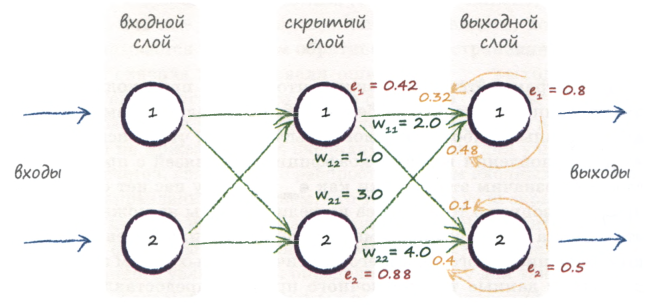

In [87]:
w11 = 2.0
w12 = 1.0
w21 = 3.0
w22 = 4.0
e1 = 0.8
e2 = 0.5

In [88]:
#code 4
w1 = np.array([w11, w21])
w2 = np.array([w12, w22])
w1/=np.sum(w1)
w2/=np.sum(w2)
err = w1*e1 + w2*e2
err
#(0.42000000000000004, 0.88)

array([0.42, 0.88])

### 4.3. **Обучение сети через уточнение весов**

Нейронные сети обучаются, корректируя веса связей. Цель — минимизировать ошибку, которая представляет собой разницу между правильным ответом (из тренировочных данных) и предсказанием сети.

> *Обучение — это итеративный процесс. На каждом шаге сеть делает предсказание, вычисляет ошибку, а затем корректирует веса, чтобы уменьшить ошибку в будущем.*

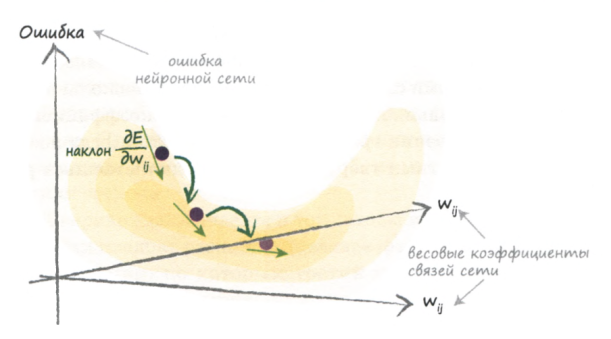

### 4.4. **Матричное представление вычислений**

Для упрощения вычислений было бы удобно представить обратное распространение ошибки в виде матричных операций. Однако это не так просто, как в случае прямого распространения сигналов.

> *Обратное распространение ошибки требует учёта множества связей и их вкладов, что делает прямое матричное умножение сложным.*

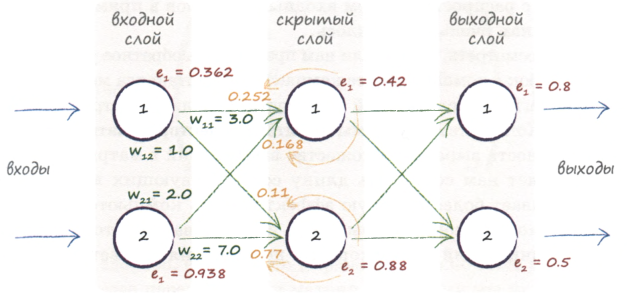

In [89]:
w11 = 3.0
w12 = 1.0
w21 = 2.0
w22 = 7.0
e1 = 0.42
e2 = 0.88

In [90]:
#code 5
w1 = np.array([w11, w21])
w2 = np.array([w12, w22])
w1/=np.sum(w1)
w2/=np.sum(w2)
err = w1*e1 + w2*e2
err
#(0.362, 0.9380000000000001)

array([0.362, 0.938])

### 4.5. **Упрощение вычислений**

Чтобы упростить вычисления, можно пренебречь нормирующим множителем в формуле распределения ошибки. Вместо точного расчёта:
$$
\frac{e_1 \cdot w_{11}}{w_{11} + w_{21}}
$$
мы используем упрощённое выражение:
$$
e_1 \cdot w_{11}
$$

> *Нормирующий множитель $ (w_{11} + w_{21}) $ нужен для точного распределения ошибки, но если его убрать, мы потеряем только масштабирование ошибки. Это упрощает вычисления, сохраняя основную идею: чем больше вес, тем больше ошибки передаётся обратно.*


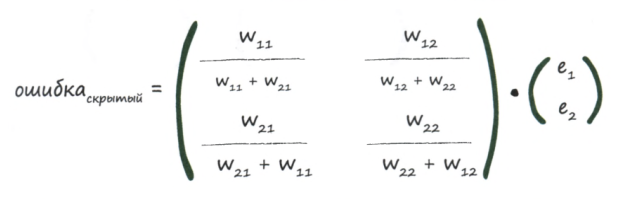

### 4.6. **Использование транспонированной матрицы весов**

Для обратного распространения ошибки используется транспонированная матрица весов $ \mathbf{w}^T $. Транспонирование — это операция, при которой строки и столбцы матрицы меняются местами.

**Пример:**  
Если исходная матрица весов $ \mathbf{w} $ выглядит так:
$$
\mathbf{w} = \begin{pmatrix}
w_{11} & w_{12} \\
w_{21} & w_{22}
\end{pmatrix},
$$
то её транспонированная версия $ \mathbf{w}^T $ будет:
$$
\mathbf{w}^T = \begin{pmatrix}
w_{11} & w_{21} \\
w_{12} & w_{22}
\end{pmatrix}.
$$

> *Транспонированная матрица позволяет корректно распределить ошибки обратно по сети, учитывая структуру связей.*

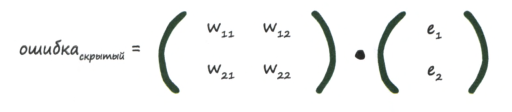

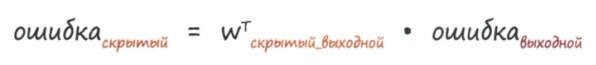

In [91]:
w = np.array([[w11, w21],[w12, w22]])
e = np.array([e1, e2])

In [92]:
#code 6
err = w.T @ e
err
#array([2.14, 7.  ])

array([2.14, 7.  ])

---
Производная частного равна разности произведения производной числителя на знаменатель и произведения числителя на производную знаменателя, деленной на квадрат знаменателя.

$
\sigma(x) = \frac{1}{1 + e^{-x}}
$

$
\frac{d(\sigma(x))}{dx} = \frac{0 \cdot (1 + e^{-x}) - (1) \cdot (e^{-x} \cdot (-1))}{(1 + e^{-x})^2}
$

$
\frac{d(\sigma(x))}{dx} = \frac{(e^{-x})}{(1 + e^{-x})^2} = \frac{1 - 1 + (e^{-x})}{(1 + e^{-x})^2} = \frac{1 + e^{-x}}{(1 + e^{-x})^2} - \frac{1}{(1 + e^{-x})^2}
$

$
\frac{d(\sigma(x))}{dx} = \frac{1}{1 + e^{-x}} \left( 1 - \frac{1}{1 + e^{-x}} \right) = \sigma(x)(1 - \sigma(x))
$

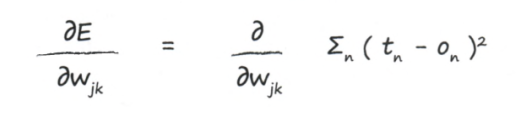

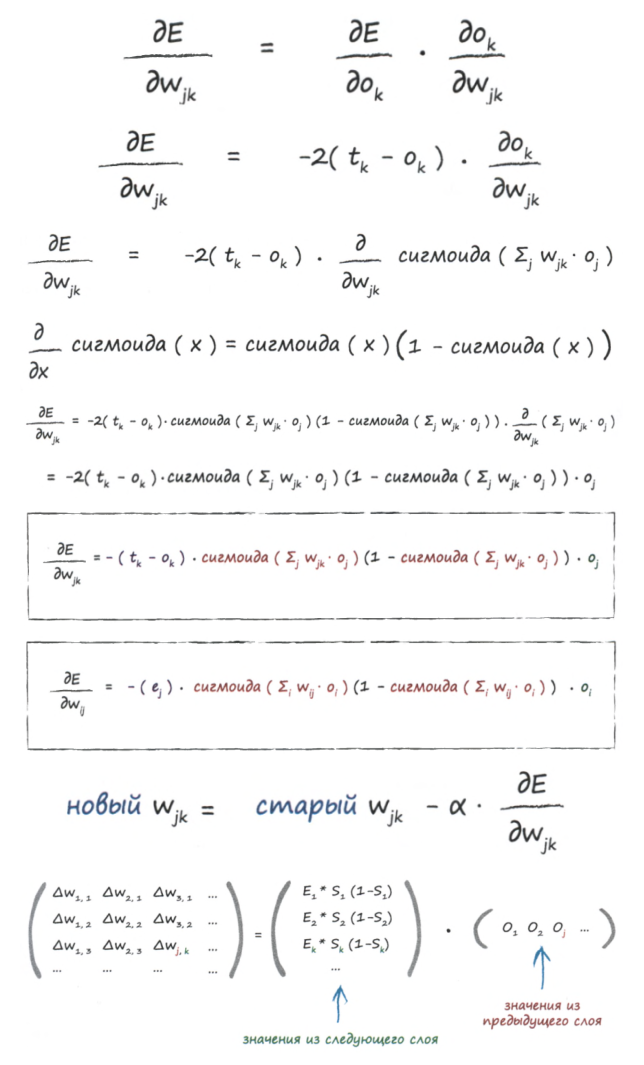

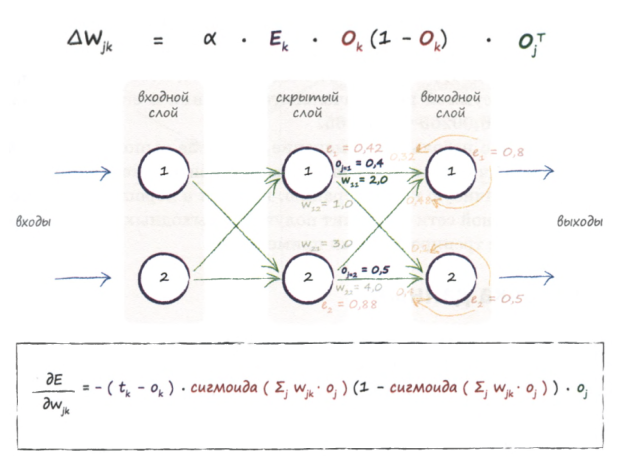

#5. **Формула обновления весов**

### 5.1. **Разбор выражения для обновления веса**

Мы рассматриваем формулу для обновления весов в процессе обратного распространения ошибки. Формула состоит из трёх частей:
1. Ошибка на выходе.
2. Производная сигмоидной функции.
3. Входной сигнал, который шёл по связи с обновляемым весом.

---

### 5.2. **Первая часть: ошибка на выходе**

Первая часть выражения — это ошибка на выходе нейрона:
$$
\mathbf{e}_1 = (\mathbf{t}_k - \mathbf{o}_k),
$$
где:
- $ \mathbf{t}_k $ — целевое значение (из тренировочных данных).
- $ \mathbf{o}_k $ — фактическое значение, выданное сетью.

В данном примере ошибка $ \mathbf{e}_1 = 0,8 $.

> *Ошибка показывает, насколько предсказание сети отличается от правильного ответа. Чем больше ошибка, тем сильнее нужно скорректировать веса.*

---

### 5.3. **Вторая часть: производная сигмоидной функции**

Вторая часть выражения связана с производной сигмоидной функции. Для нейрона с суммой входных сигналов $ x = 2,3 $ (рассчитанной как $ 2,0 \cdot 0,4 + 3,0 \cdot 0,5 $), сигмоида равна:
$$
\sigma(x) = \frac{1}{1 + e^{-2,3}} \approx 0,909.
$$

Производная сигмоидной функции вычисляется как:
$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x)) = 0,909 \cdot (1 - 0,909) \approx 0,083.
$$

> *Производная сигмоидной функции показывает, насколько чувствителен выход нейрона к изменению его входа. Это важно для понимания, как сильно нужно скорректировать веса.*

---

### 5.4. **Третья часть: входной сигнал**

Третья часть выражения — это входной сигнал $ \mathbf{o}_j $, который шёл по связи с обновляемым весом. В данном случае $ \mathbf{o}_j = 0,4 $.

> *Этот сигнал показывает, какой вклад внёс данный вес в ошибку. Чем больше входной сигнал, тем сильнее нужно скорректировать вес.*

---

### 5.5. **Объединение всех частей**

Теперь объединим все три части:
$$
\Delta w_{11} = -\mathbf{e}_1 \cdot \sigma'(x) \cdot \mathbf{o}_j = -0,8 \cdot 0,083 \cdot 0,4 \approx -0,0265.
$$

> *Знак "минус" указывает на то, что мы корректируем вес в направлении, противоположном ошибке, чтобы уменьшить её.*

---

### 5.6. **Применение коэффициента обучения**

Коэффициент обучения $ \eta $ (в данном случае $ \eta = 0,1 $) определяет, насколько сильно мы изменяем вес:
$$
\Delta w_{11} = \eta \cdot (-0,0265) = 0,1 \cdot (-0,0265) = -0,00265.
$$

Новое значение веса:
$$
w_{11} = w_{11} + \Delta w_{11} = 2,0 + 0,00265 = 2,00265.
$$

> *Коэффициент обучения контролирует скорость обучения. Если он слишком большой, сеть может "перескакивать" оптимальные значения весов. Если слишком маленький, обучение будет медленным.*

> *Этот процесс повторяется для всех весов сети на каждой итерации обучения. После множества итераций веса стабилизируются, и сеть начинает выдавать более точные предсказания.*

In [93]:
o1 = 0.4
o2 = 0.5
w11 = 2.0
w12 = 1.0
w21 = 3.0
w22 = 4.0
e1 = 0.8
e2 = 0.5

In [94]:
e = np.array([e1, e2])
w = np.array([[w11, w12], 
              [w21, w22]])
o = np.array([o1, o2])

In [95]:
s11 = sigmoid(w11*o1 + w21*o2)
s12 = sigmoid(w12*o1 + w22*o2)
s21 = sigmoid(w11*o1 + w21*o2)
s22 = sigmoid(w12*o1 + w22*o2)
s11

0.9088770389851438

In [96]:
#code 7 
he = w.T @ e
s = w @ o 
dw = (e * s * (1. - s)).T @ o

dw11 = -e1*s11*(1 - s12)*o1
dw12 = -e2*s12*(1 - s12)*o1
dw21 = -e1*s21*(1 - s21)*o2
dw22 = -e2*s22*(1 - s22)*o2
w11 - dw11, w12 - dw12, w21 - dw21, w22 - dw22
#dw11, dw12, dw21, dw22
#0.9088770389851438
#0.08281956699074118
#0.002650226143703718
#2.002650226143704 итоговое

(2.024190001316418, 1.0152509998103705, 3.0331278267962967, 4.019063749762963)

In [104]:
import numpy as np
from scipy.special import expit as sigmoid
from dataclasses import dataclass
norm = np.random.normal

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
y = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

@dataclass
class NeuralNetwork:
  inp: ... # input  nodes
  hid: ... # hidden nodes
  out: ... # output nodes
  lr:  ... # learning rate
  act: ... # activation function
  epo: ... # epochs

  def __post_init__(s): # generate weights
    s.wih = norm(0., np.sqrt(s.inp), (s.hid, s.inp))
    s.who = norm(0., np.sqrt(s.hid), (s.out, s.hid))

  def train(s, x, y):
    x = np.array(x, ndmin=2).T
    y = np.array(y, ndmin=2).T

    ho = s.act(s.wih @ x)  # hidden outputs
    fo = s.act(s.who @ ho) # final  outputs
    oe = y - fo            # output errors
    he = s.who.T @ oe      # hidden errors
    s.who += s.lr * (oe * fo * (1. - fo)) @ ho.T
    s.wih += s.lr * (he * ho * (1. - ho)) @ x.T

  def query(s, x):
    x = np.array(x, ndmin=2).T
    return s.act(s.who @ s.act(s.wih @ x))

  def fit(s, X, y):
    for e in range(s.epo):
      for i in range(len(y)):
        s.train(X[i], y[i])

  def predict(s, X):
    return np.array([np.argmax(s.query(x)) for x in X])

  def score(s, X, y):
    y = np.array([np.argmax(i) for i in y])
    return (s.predict(X) == y).mean()

nn = NeuralNetwork(X.shape[1], 10, y.shape[1], 0.1, sigmoid, 50)
nn.fit(X_train, y_train)
nn.score(X_test, y_test)

0.9736842105263158

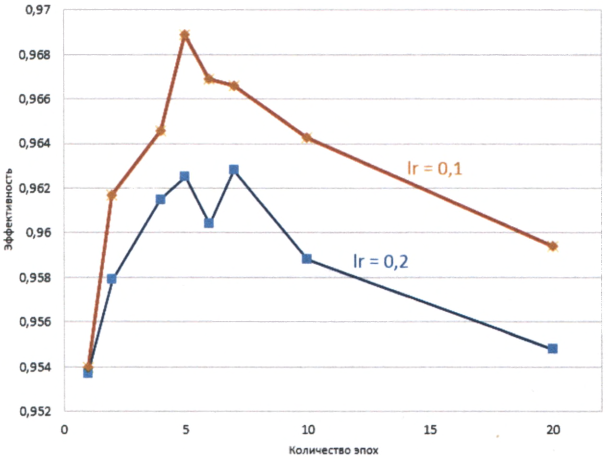

In [105]:
#code 8
# Постройте подобный график
# Меняйте learning rate и hidden nodes
# Замеры надо проводить несколько раз и усреднять
# Шаг количества эпох не берите сильно частый

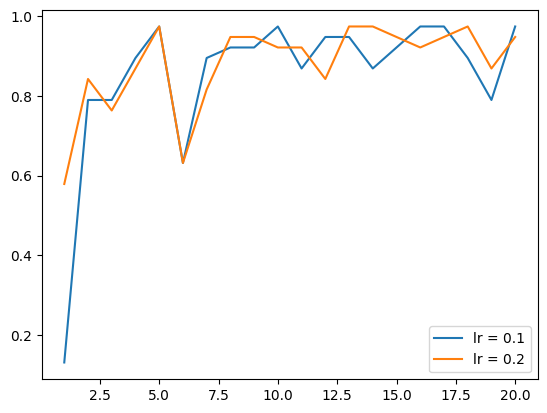

In [108]:
import matplotlib.pyplot as plt

n_epochs = [i for i in range(1, 21)]
lr1_score = []
lr2_score = []
for e in n_epochs:

    nn_lr1 = NeuralNetwork(X.shape[1], 10, y.shape[1], 0.1, sigmoid, e)
    nn_lr2 = NeuralNetwork(X.shape[1], 10, y.shape[1], 0.2, sigmoid, e)

    nn_lr1.fit(X_train, y_train)
    lr1_score.append(nn_lr1.score(X_test, y_test))

    nn_lr2.fit(X_train, y_train)
    lr2_score.append(nn_lr2.score(X_test, y_test))

plt.plot(n_epochs, lr1_score, label = "lr = 0.1")
plt.plot(n_epochs, lr2_score, label = "lr = 0.2")
plt.legend()

In [123]:
import numpy as np
from scipy.special import expit as sigmoid
from scipy.special import logit
from dataclasses import dataclass
from tqdm import tqdm
norm = np.random.normal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

import keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0],   -1)
X_train = (X_train.astype("float32") / 255.0 * 0.98) + 0.01
X_test  = (X_test.astype("float32")  / 255.0 * 0.98) + 0.01
y_train = OneHotEncoder().fit_transform(y_train.reshape(-1, 1)).toarray()
y_test  = OneHotEncoder().fit_transform(y_test.reshape(-1, 1) ).toarray()
y_train = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(y_train)
y_test  = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(y_test )


@dataclass
class NeuralNetwork:
  inp: ... # input  nodes
  hid: ... # hidden nodes
  out: ... # output nodes
  lr:  ... # learning rate
  act: ... # activation function
  inv: ... # inverse activation function
  epo: ... # epochs

  def __post_init__(s): # generate weights
    s.wih = norm(0., np.sqrt(1/s.inp), (s.hid, s.inp))
    s.who = norm(0., np.sqrt(1/s.hid), (s.out, s.hid))

  def train(s, x, y):
    x = np.array(x, ndmin=2).T
    y = np.array(y, ndmin=2).T

    ho = s.act(s.wih @ x)  # hidden outputs
    fo = s.act(s.who @ ho) # final  outputs
    oe = y - fo            # output errors
    he = s.who.T @ oe      # hidden errors
    s.who += s.lr * (oe * fo * (1. - fo)) @ ho.T
    s.wih += s.lr * (he * ho * (1. - ho)) @ x.T

  def query(s, x):
    x = np.array(x, ndmin=2).T
    return s.act(s.who @ s.act(s.wih @ x))

  def backquery(s, y):

    final_outputs = np.array(y, ndmin=2).T

    # calculate the signal into the final output layer
    final_inputs = s.inv(final_outputs)

    # calculate the signal out of the hidden layer
    hidden_outputs = np.dot(s.who.T, final_inputs)
    # scale them back to 0.01 to .99
    hidden_outputs -= np.min(hidden_outputs)
    hidden_outputs /= np.max(hidden_outputs)
    hidden_outputs *= 0.98
    hidden_outputs += 0.01

    # calculate the signal into the hidden layer
    hidden_inputs = s.inv(hidden_outputs)

    # calculate the signal out of the input layer
    inputs = np.dot(s.wih.T, hidden_inputs)
    # scale them back to 0.01 to .99
    inputs -= np.min(inputs)
    inputs /= np.max(inputs)
    inputs *= 0.98
    inputs += 0.01

    return inputs

  def fit(s, X, y):
    for e in tqdm(range(s.epo)):
      for i in range(len(y)):
        s.train(X[i], y[i])

  def predict(s, X):
    return np.array([np.argmax(s.query(x)) for x in X])

  def score(s, X, y):
    y = np.array([np.argmax(i) for i in y])
    return (s.predict(X) == y).mean()

nn = NeuralNetwork(X_train.shape[1], 200, y_train.shape[1], 0.1, sigmoid, logit, 10)#200 5
nn.fit(X_train, y_train)
print(nn.score(X_test, y_test))

100%|██████████| 10/10 [07:56<00:00, 47.62s/it]


0.9735


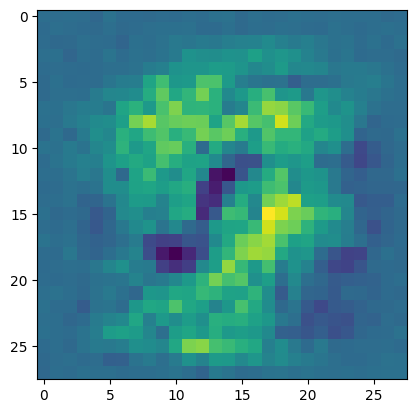

In [126]:
img = nn.backquery(y_test[0])
img = img.reshape(28, 28)
plt.imshow(img)

In [117]:
img.shape

(784, 1)

In [100]:
#code 9
# Напишите метод backquery
#code 10
# Покажите какие картинки получились на входе

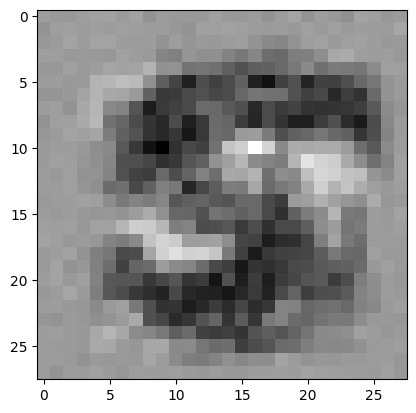

### Заключение

Нейронные сети представляют собой мощный инструмент для решения сложных задач, связанных с обработкой данных, распознаванием образов и прогнозированием. В этой работе мы рассмотрели основные принципы их функционирования, начиная с базовых понятий, таких как структура нейрона, роль весовых коэффициентов и функции активации, и заканчивая более сложными аспектами, такими как обратное распространение ошибки и обновление весов.

#### 6.1. Итоги работы нейронной сети
Нейронные сети способны обучаться на данных, постепенно улучшая свои предсказания за счёт корректировки весовых коэффициентов. Мы увидели, как входные сигналы преобразуются через взвешенные суммы и функции активации, а также как ошибка распространяется обратно по сети для настройки весов. Это позволяет сети адаптироваться к данным и минимизировать ошибку.

#### 6.2. Важность итеративного обучения
Обучение нейронной сети — это итеративный процесс, который требует множества шагов для достижения оптимальных результатов. На каждом этапе сеть корректирует свои веса, чтобы уменьшить разницу между предсказанными и фактическими значениями. Коэффициент обучения играет ключевую роль в этом процессе, определяя скорость и стабильность обучения.

#### 6.3. Перспективы использования нейронных сетей
Нейронные сети уже нашли применение в различных областях, таких как компьютерное зрение, обработка естественного языка, медицинская диагностика и многое другое. Однако их потенциал ещё не исчерпан. С развитием технологий и появлением новых архитектур, таких как свёрточные сети (CNN) и трансформеры, возможности нейронных сетей продолжают расширяться. (*Ниже список актуальных архитектур и подходов*)

> *В будущем нейронные сети, вероятно, станут ещё более интегрированными в нашу повседневную жизнь, помогая решать задачи, которые сегодня кажутся невыполнимыми. Их развитие продолжается, и каждый новый прорыв в этой области приносит нам всё больше возможностей для улучшения качества жизни и решения глобальных проблем.*



Список актуальных архитектур и подходов, которые активно используются или исследуются в области глубокого обучения:

#### 1. **Рекуррентные нейронные сети (RNN) и их вариации**
   - **RNN**: Используются для обработки последовательностей данных, таких как временные ряды или текст.
   - **LSTM (Long Short-Term Memory)**: Улучшенная версия RNN, способная запоминать долгосрочные зависимости.
   - **GRU (Gated Recurrent Units)**: Упрощённая версия LSTM, которая также эффективно работает с последовательностями.

#### 2. **Генеративно-состязательные сети (GAN)**
   - **GAN**: Состоят из двух сетей — генератора и дискриминатора, которые соревнуются друг с другом. Используются для генерации реалистичных изображений, видео и других данных.
   - **CycleGAN**: Вариация GAN для задач преобразования изображений, например, перевод изображений из одного стиля в другой.
   - **StyleGAN**: Архитектура, специализирующаяся на генерации высококачественных изображений с контролируемыми стилевыми характеристиками.

#### 3. **Автокодировщики (Autoencoders)**
   - **Обычные автокодировщики**: Используются для сжатия данных и обучения представлений.
   - **Вариационные автокодировщики (VAE)**: Генеративные модели, которые учатся распределению данных и могут создавать новые примеры.
   - **Denoising Autoencoders**: Автокодировщики, которые учатся восстанавливать данные из зашумлённых входов.

#### 4. **Трансформеры (Transformers)**
   - **Трансформеры**: Архитектура, основанная на механизме внимания (attention), которая революционизировала обработку естественного языка (NLP).
   - **BERT (Bidirectional Encoder Representations from Transformers)**: Модель для предварительного обучения на текстовых данных, которая учитывает контекст с обеих сторон.
   - **GPT (Generative Pre-trained Transformer)**: Серия моделей, способных генерировать текст, близкий к человеческому.
   - **Vision Transformers (ViT)**: Применение трансформеров для задач компьютерного зрения.

#### 5. **Графовые нейронные сети (GNN)**
   - **GNN**: Используются для работы с графами, такими как социальные сети, молекулярные структуры или транспортные системы.
   - **Graph Convolutional Networks (GCN)**: Применяют свёрточные операции к графам.
   - **Graph Attention Networks (GAT)**: Используют механизмы внимания для работы с графами.

#### 6. **Нейронные сети с вниманием (Attention Mechanisms)**
   - **Self-Attention**: Механизм, который позволяет модели учитывать зависимости между всеми элементами последовательности.
   - **Multi-Head Attention**: Расширение self-attention, которое позволяет модели фокусироваться на разных аспектах данных одновременно.

#### 7. **Нейронные сети для обработки временных рядов**
   - **Temporal Convolutional Networks (TCN)**: Используют свёрточные слои для анализа временных данных.
   - **N-BEATS**: Архитектура, разработанная специально для прогнозирования временных рядов.

#### 8. **Метаобучение (Meta-Learning)**
   - **MAML (Model-Agnostic Meta-Learning)**: Подход, который позволяет модели быстро адаптироваться к новым задачам с минимальным количеством данных.
   - **Reptile**: Упрощённый алгоритм метаобучения, который также эффективен для быстрой адаптации.

#### 9. **Нейронные сети для обработки мультимодальных данных**
   - **CLIP (Contrastive Language–Image Pretraining)**: Модель, которая учится связывать текст и изображения.
   - **DALL-E**: Модель, способная генерировать изображения на основе текстовых описаний.

#### 10. **Спайковые нейронные сети (Spiking Neural Networks, SNN)**
   - **SNN**: Модели, которые имитируют работу биологических нейронов, используя спайки (импульсы) для передачи информации. Это направление активно исследуется в области нейроморфных вычислений.

#### 11. **Нейронные сети с подкреплением (Reinforcement Learning, RL)**
   - **Deep Q-Networks (DQN)**: Используют глубокие нейронные сети для обучения агентов в средах с подкреплением.
   - **Proximal Policy Optimization (PPO)**: Популярный алгоритм для обучения политик в RL.
   - **AlphaZero**: Модель, которая сочетает RL и поиск по дереву для достижения сверхчеловеческого уровня в играх.

#### 12. **Нейронные сети для обработки звука и речи**
   - **WaveNet**: Модель для генерации реалистичного звука и речи.
   - **Tacotron**: Архитектура для синтеза речи из текста.

#### 13. **Нейронные сети для обработки медицинских данных**
   - **U-Net**: Архитектура для сегментации изображений, широко используемая в медицинской диагностике.
   - **3D CNN**: Используются для анализа трёхмерных медицинских данных, таких как МРТ или КТ.

#### 14. **Энергоэффективные и компактные модели**
   - **MobileNet**: Свёрточные сети, оптимизированные для мобильных устройств.
   - **EfficientNet**: Архитектура, которая обеспечивает высокую точность при минимальных вычислительных затратах.
   - **Knowledge Distillation**: Метод, позволяющий "сжимать" большие модели в более компактные, сохраняя их производительность.

#### 15. **Нейронные сети для обработки неструктурированных данных**
   - **Transformer-based Models for Tabular Data**: Применение трансформеров для работы с табличными данными.
   - **Deep Learning for Graphs and Networks**: Модели, которые работают с графами и сетями, такими как социальные графы или молекулярные структуры.

#### 16. **Гибридные подходы**
   - **Neuro-Symbolic AI**: Сочетание нейронных сетей и символических методов для улучшения интерпретируемости и логического вывода.
   - **Deep Reinforcement Learning with Memory**: Модели, которые сочетают RL с механизмами памяти для решения сложных задач.

Эти архитектуры и подходы демонстрируют, насколько разнообразны и мощны современные методы глубокого обучения. Каждая из них решает определённые задачи и открывает новые возможности для применения в различных областях, от компьютерного зрения и обработки естественного языка до медицины и робототехники.